In [1]:
from pathlib import Path
from math import gcd
from urllib.request import urlretrieve
import copy
import json
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import soundfile as sf
from scipy.signal import resample_poly

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from panns_inference import AudioTagging, labels as PANNS_LABELS

from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    confusion_matrix,
    f1_score,
    precision_score,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
)

In [2]:
AUDIO_DIR = Path(".")
PROJECT_ROOT = Path("..")
DATA_DIR = PROJECT_ROOT / "data"
META_DIR = DATA_DIR / "metadata"

MODEL_MANIFEST_PATH = (
    META_DIR / "benchmark_2_audio_model_manifest.csv"
)

MODELS_DIR = AUDIO_DIR / "models"
RESULTS_DIR = AUDIO_DIR / "results"
PRETRAINED_DIR = MODELS_DIR / "pretrained"

MODELS_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
PRETRAINED_DIR.mkdir(parents=True, exist_ok=True)

In [12]:
PANNS_CHECKPOINT_URL = (
    "https://zenodo.org/record/3987831/files/"
    "Cnn14_mAP%3D0.431.pth?download=1"
)

PANNS_CHECKPOINT_PATH = (
    PRETRAINED_DIR / "Cnn14_mAP=0.431.pth"
)

PANNS_SAMPLE_RATE = 32_000

# Main strong baseline. This stays configurable.
CONTEXT_SECONDS = 2.0
DURATION_TOLERANCE_S = 0.05

TARGET_ANIMAL_RECALL = 0.95
RANDOM_SEED = 42

# Binary head
HEAD_HIDDEN_DIM = 256
HEAD_DROPOUT = 0.30
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
BATCH_SIZE = 64
MAX_EPOCHS = 150
EARLY_STOPPING_PATIENCE = 20

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

CONTEXT_TAG = str(CONTEXT_SECONDS).replace(".", "p")

FEATURE_CACHE_PATH = (
    RESULTS_DIR / f"panns_cnn14_features_{CONTEXT_TAG}s.npz"
)

HEAD_PATH = (
    MODELS_DIR / f"panns_cnn14_binary_head_{CONTEXT_TAG}s.pt"
)

METRICS_PATH = (
    RESULTS_DIR / f"panns_cnn14_metrics_{CONTEXT_TAG}s.csv"
)

CONFIG_PATH = (
    RESULTS_DIR / f"panns_cnn14_config_{CONTEXT_TAG}s.json"
)

torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)

print("Device:", DEVICE)
print("Manifest:", MODEL_MANIFEST_PATH)
print("Context:", CONTEXT_SECONDS, "s")
print("Target animal recall:", TARGET_ANIMAL_RECALL)

Device: cuda
Manifest: ..\data\metadata\benchmark_2_audio_model_manifest.csv
Context: 2.0 s
Target animal recall: 0.95


In [4]:
manifest = pd.read_csv(MODEL_MANIFEST_PATH)

required_columns = {
    "sample_id",
    "event_id",
    "file_id",
    "anchor_s",
    "duration",
    "binary_label",
    "label_name",
    "site_id",
    "cam_id",
    "audio_path",
    "dataset_split",
}

missing_columns = required_columns - set(manifest.columns)

assert not missing_columns, (
    "Missing manifest columns: "
    f"{sorted(missing_columns)}. "
    "Run Prepare_Audio_Data.ipynb first."
)

assert set(manifest["dataset_split"].unique()) <= {
    "train", "val", "test"
}

assert (
    manifest
    .groupby("event_id")["dataset_split"]
    .nunique()
    .max()
    == 1
)

eligible = manifest[
    manifest["duration"] >= CONTEXT_SECONDS
].copy()

print("Manifest samples:", len(manifest))
print("Eligible samples:", len(eligible))
print("Eligible events:", eligible["event_id"].nunique())

display(
    eligible
    .groupby(["dataset_split", "label_name"])
    .agg(
        samples=("sample_id", "count"),
        events=("event_id", "nunique"),
        files=("file_id", "nunique"),
    )
)


Manifest samples: 908
Eligible samples: 908
Eligible events: 389


samples  events  files
dataset_split label_name                        
test          animal          123      57    117
              background       84      28     48
train         animal          436     203    425
              background      120      40     59
val           animal          115      51    111
              background       30      10     19

In [13]:
def choose_window(
    anchor_s,
    duration_s,
    context_s,
    tolerance_s=DURATION_TOLERANCE_S,
):
    if duration_s < context_s - tolerance_s:
        raise ValueError(
            f"Source duration {duration_s:.3f}s is shorter "
            f"than context {context_s:.3f}s."
        )

    effective_duration = max(
        duration_s,
        context_s,
    )

    start_s = np.clip(
        anchor_s - context_s / 2,
        0,
        effective_duration - context_s,
    )

    return (
        float(start_s),
        float(start_s + context_s),
    )


In [14]:
def resample_waveform(waveform, source_sr, target_sr):
    if source_sr == target_sr:
        return waveform.astype(np.float32, copy=False)

    divisor = gcd(int(source_sr), int(target_sr))

    return resample_poly(
        waveform,
        up=target_sr // divisor,
        down=source_sr // divisor,
    ).astype(np.float32)


In [15]:
def load_panns_waveform(row, context_s=CONTEXT_SECONDS):
    audio_path = Path(row["audio_path"])

    if not audio_path.exists():
        raise FileNotFoundError(
            f"Missing cached audio: {audio_path}"
        )

    with sf.SoundFile(audio_path) as audio_file:
        source_sr = int(audio_file.samplerate)
        actual_duration = len(audio_file) / source_sr

        duration_s = min(
            float(row["duration"]),
            float(actual_duration),
        )

        start_s, _ = choose_window(
            anchor_s=float(row["anchor_s"]),
            duration_s=duration_s,
            context_s=context_s,
        )

        start_frame = round(start_s * source_sr)
        frames_to_read = round(context_s * source_sr)

        audio_file.seek(start_frame)

        waveform = audio_file.read(
            frames=frames_to_read,
            dtype="float32",
            always_2d=False,
        )

    if waveform.ndim == 2:
        waveform = waveform.mean(axis=1)

    waveform = resample_waveform(
        waveform,
        source_sr,
        PANNS_SAMPLE_RATE,
    )

    target_samples = round(
        context_s * PANNS_SAMPLE_RATE
    )

    if len(waveform) > target_samples:
        waveform = waveform[:target_samples]

    elif len(waveform) < target_samples:
        waveform = np.pad(
            waveform,
            (0, target_samples - len(waveform)),
        )

    return np.clip(
        waveform,
        -1.0,
        1.0,
    ).astype(np.float32)


In [16]:
if not PANNS_CHECKPOINT_PATH.exists():
    print("Downloading pretrained PANNs Cnn14 checkpoint...")
    urlretrieve(
        PANNS_CHECKPOINT_URL,
        PANNS_CHECKPOINT_PATH,
    )
    print("Saved:", PANNS_CHECKPOINT_PATH)
else:
    print(
        "Checkpoint already available:",
        PANNS_CHECKPOINT_PATH,
    )

panns = AudioTagging(
    checkpoint_path=str(PANNS_CHECKPOINT_PATH),
    device="cuda" if DEVICE.type == "cuda" else "cpu",
)

panns_model = (
    panns.model.module
    if isinstance(panns.model, torch.nn.DataParallel)
    else panns.model
)

backbone_parameters = sum(
    p.numel()
    for p in panns_model.parameters()
)

print(
    f"PANNs Cnn14 parameters: "
    f"{backbone_parameters / 1e6:.2f} M"
)

print("\nBackbone blocks:")
for name in [
    "conv_block1",
    "conv_block2",
    "conv_block3",
    "conv_block4",
    "conv_block5",
    "conv_block6",
]:
    print(" -", name)


Checkpoint already available: models\pretrained\Cnn14_mAP=0.431.pth
Checkpoint path: models\pretrained\Cnn14_mAP=0.431.pth
GPU number: 1
PANNs Cnn14 parameters: 81.84 M

Backbone blocks:
 - conv_block1
 - conv_block2
 - conv_block3
 - conv_block4
 - conv_block5
 - conv_block6


In [17]:
example_row = eligible.iloc[0]

example_waveform = load_panns_waveform(
    example_row
)

clipwise_output, embedding = panns.inference(
    example_waveform[None, :]
)

print("True label:", example_row["label_name"])
print("Waveform shape:", example_waveform.shape)
print("Clipwise output:", clipwise_output.shape)
print("Embedding:", embedding.shape)

top_indices = np.argsort(
    clipwise_output[0]
)[-10:][::-1]

print("\nTop pretrained PANNs classes:")

for idx in top_indices:
    print(
        f"{PANNS_LABELS[idx]:35s} "
        f"{clipwise_output[0, idx]:.4f}"
    )

animal_indices = [
    i
    for i, name in enumerate(PANNS_LABELS)
    if name.lower() == "animal"
]

if animal_indices:
    ANIMAL_CLASS_INDEX = animal_indices[0]

    print(
        "\nPretrained 'Animal' score:",
        float(
            clipwise_output[
                0,
                ANIMAL_CLASS_INDEX
            ]
        ),
    )
else:
    ANIMAL_CLASS_INDEX = None
    print("\nNo exact 'Animal' class found.")


True label: animal
Waveform shape: (64000,)
Clipwise output: (1, 527)
Embedding: (1, 2048)

Top pretrained PANNs classes:
Sine wave                           0.0909
Silence                             0.0885
White noise                         0.0724
Vehicle                             0.0436
Music                               0.0387
Mouse                               0.0267
Speech                              0.0259
Inside, small room                  0.0248
Animal                              0.0218
Tuning fork                         0.0188

Pretrained 'Animal' score: 0.02176065370440483


In [18]:
def extract_panns_features(df, batch_size=16):
    embeddings_out = []
    animal_scores_out = []

    start_time = time.perf_counter()

    for batch_start in range(
        0,
        len(df),
        batch_size,
    ):
        batch_df = df.iloc[
            batch_start:
            batch_start + batch_size
        ]

        batch_audio = np.stack(
            [
                load_panns_waveform(row)
                for _, row in batch_df.iterrows()
            ]
        )

        clipwise_output, embedding = (
            panns.inference(batch_audio)
        )

        embeddings_out.append(
            embedding.astype(np.float32)
        )

        if ANIMAL_CLASS_INDEX is not None:
            animal_scores_out.append(
                clipwise_output[
                    :,
                    ANIMAL_CLASS_INDEX
                ].astype(np.float32)
            )

        completed = min(
            batch_start + batch_size,
            len(df),
        )

        if (
            completed % 100 < batch_size
            or completed == len(df)
        ):
            elapsed = (
                time.perf_counter()
                - start_time
            )

            print(
                f"{completed}/{len(df)} "
                f"samples ({elapsed:.1f}s)"
            )

    X = np.concatenate(
        embeddings_out,
        axis=0,
    )

    if animal_scores_out:
        animal_scores = np.concatenate(
            animal_scores_out,
            axis=0,
        )
    else:
        animal_scores = np.full(
            len(df),
            np.nan,
            dtype=np.float32,
        )

    return X, animal_scores


In [19]:
current_sample_ids = (
    eligible["sample_id"]
    .astype(str)
    .to_numpy()
)

if FEATURE_CACHE_PATH.exists():
    cached = np.load(
        FEATURE_CACHE_PATH,
        allow_pickle=True,
    )

    cached_sample_ids = (
        cached["sample_ids"]
        .astype(str)
    )

    if not np.array_equal(
        current_sample_ids,
        cached_sample_ids,
    ):
        raise RuntimeError(
            "Feature cache exists but sample IDs do not "
            "match the current manifest. Delete the cache "
            "and rerun this cell."
        )

    X = cached["embeddings"]
    pretrained_animal_score = cached[
        "animal_scores"
    ]

    print(
        "Loaded cached PANNs features:",
        FEATURE_CACHE_PATH,
    )

else:
    X, pretrained_animal_score = (
        extract_panns_features(
            eligible,
            batch_size=16,
        )
    )

    np.savez_compressed(
        FEATURE_CACHE_PATH,
        embeddings=X,
        animal_scores=pretrained_animal_score,
        sample_ids=current_sample_ids,
    )

    print(
        "Saved feature cache:",
        FEATURE_CACHE_PATH,
    )

print("Feature matrix:", X.shape)

assert X.shape == (
    len(eligible),
    2048,
)


112/908 samples (1.3s)
208/908 samples (1.9s)
304/908 samples (2.6s)
400/908 samples (3.3s)
512/908 samples (4.0s)
608/908 samples (4.6s)
704/908 samples (5.1s)
800/908 samples (5.8s)
908/908 samples (6.5s)
Saved feature cache: results\panns_cnn14_features_2p0s.npz
Feature matrix: (908, 2048)


In [20]:
y = (
    eligible["binary_label"]
    .astype(np.float32)
    .to_numpy()
)

splits = eligible[
    "dataset_split"
].to_numpy()

train_mask = splits == "train"
val_mask = splits == "val"
test_mask = splits == "test"

X_train = X[train_mask]
X_val = X[val_mask]
X_test = X[test_mask]

y_train = y[train_mask]
y_val = y[val_mask]
y_test = y[test_mask]

print("Train:", X_train.shape)
print("Val:  ", X_val.shape)
print("Test: ", X_test.shape)

for split_name, labels in [
    ("train", y_train),
    ("val", y_val),
    ("test", y_test),
]:
    values, counts = np.unique(
        labels.astype(int),
        return_counts=True,
    )

    print(
        split_name,
        dict(zip(values, counts)),
    )


Train: (556, 2048)
Val:   (145, 2048)
Test:  (207, 2048)
train {np.int64(0): np.int64(120), np.int64(1): np.int64(436)}
val {np.int64(0): np.int64(30), np.int64(1): np.int64(115)}
test {np.int64(0): np.int64(84), np.int64(1): np.int64(123)}


In [21]:
class BinaryHead(nn.Module):
    def __init__(
        self,
        input_dim=2048,
        hidden_dim=256,
        dropout=0.30,
    ):
        super().__init__()

        self.network = nn.Sequential(
            nn.LayerNorm(input_dim),
            nn.Linear(
                input_dim,
                hidden_dim,
            ),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(
                hidden_dim,
                1,
            ),
        )

    def forward(self, x):
        return (
            self.network(x)
            .squeeze(-1)
        )


head = BinaryHead(
    input_dim=2048,
    hidden_dim=HEAD_HIDDEN_DIM,
    dropout=HEAD_DROPOUT,
).to(DEVICE)

head_parameters = sum(
    p.numel()
    for p in head.parameters()
)

print(
    f"Binary head parameters: "
    f"{head_parameters / 1e6:.3f} M"
)

print(
    f"Full deployed parameters: "
    f"{(backbone_parameters + head_parameters) / 1e6:.2f} M"
)


Binary head parameters: 0.529 M
Full deployed parameters: 82.37 M


In [22]:
X_train_tensor = torch.from_numpy(
    X_train
).float()

y_train_tensor = torch.from_numpy(
    y_train
).float()

X_val_tensor = torch.from_numpy(
    X_val
).float()

y_val_tensor = torch.from_numpy(
    y_val
).float()

train_loader = DataLoader(
    TensorDataset(
        X_train_tensor,
        y_train_tensor,
    ),
    batch_size=BATCH_SIZE,
    shuffle=True,
)

n_positive = float(
    (y_train == 1).sum()
)

n_negative = float(
    (y_train == 0).sum()
)

pos_weight = torch.tensor(
    [n_negative / n_positive],
    dtype=torch.float32,
    device=DEVICE,
)

criterion = nn.BCEWithLogitsLoss(
    pos_weight=pos_weight
)

optimizer = torch.optim.AdamW(
    head.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)

print(
    "Positive class weight:",
    float(pos_weight.item()),
)


Positive class weight: 0.2752293646335602


In [23]:
def evaluate_loss(
    model,
    features,
    labels,
):
    model.eval()

    with torch.no_grad():
        logits = model(
            features.to(DEVICE)
        )

        loss = criterion(
            logits,
            labels.to(DEVICE),
        )

    return float(loss.item())

In [24]:
best_state = None
best_val_loss = np.inf
epochs_without_improvement = 0

history = []

for epoch in range(
    1,
    MAX_EPOCHS + 1,
):
    head.train()

    train_loss_sum = 0.0
    train_items = 0

    for batch_x, batch_y in train_loader:
        batch_x = batch_x.to(DEVICE)
        batch_y = batch_y.to(DEVICE)

        optimizer.zero_grad()

        logits = head(batch_x)

        loss = criterion(
            logits,
            batch_y,
        )

        loss.backward()
        optimizer.step()

        train_loss_sum += (
            loss.item()
            * len(batch_x)
        )

        train_items += len(batch_x)

    train_loss = (
        train_loss_sum
        / train_items
    )

    val_loss = evaluate_loss(
        head,
        X_val_tensor,
        y_val_tensor,
    )

    history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "val_loss": val_loss,
    })

    if val_loss < best_val_loss - 1e-5:
        best_val_loss = val_loss

        best_state = copy.deepcopy(
            head.state_dict()
        )

        epochs_without_improvement = 0

    else:
        epochs_without_improvement += 1

    if epoch == 1 or epoch % 10 == 0:
        print(
            f"Epoch {epoch:3d} | "
            f"train={train_loss:.4f} | "
            f"val={val_loss:.4f}"
        )

    if (
        epochs_without_improvement
        >= EARLY_STOPPING_PATIENCE
    ):
        print(
            "Early stopping at epoch",
            epoch,
        )
        break

head.load_state_dict(best_state)

torch.save(
    {
        "head_state_dict":
            head.state_dict(),
        "input_dim":
            2048,
        "hidden_dim":
            HEAD_HIDDEN_DIM,
        "dropout":
            HEAD_DROPOUT,
        "context_seconds":
            CONTEXT_SECONDS,
    },
    HEAD_PATH,
)

print("Saved best head:", HEAD_PATH)


Epoch   1 | train=0.2964 | val=0.2984
Epoch  10 | train=0.1654 | val=0.1876
Epoch  20 | train=0.1330 | val=0.1807
Epoch  30 | train=0.1423 | val=0.1896
Early stopping at epoch 32
Saved best head: models\panns_cnn14_binary_head_2p0s.pt


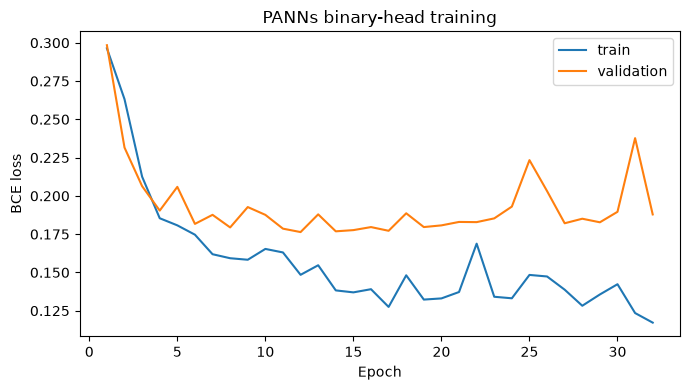

In [25]:
history_df = pd.DataFrame(history)

plt.figure(figsize=(7, 4))

plt.plot(
    history_df["epoch"],
    history_df["train_loss"],
    label="train",
)

plt.plot(
    history_df["epoch"],
    history_df["val_loss"],
    label="validation",
)

plt.xlabel("Epoch")
plt.ylabel("BCE loss")
plt.title("PANNs binary-head training")
plt.legend()
plt.tight_layout()
plt.show()


In [26]:
def predict_probabilities(
    model,
    features,
):
    model.eval()

    tensor = torch.from_numpy(
        features
    ).float().to(DEVICE)

    with torch.no_grad():
        logits = model(tensor)

        probabilities = torch.sigmoid(
            logits
        )

    return (
        probabilities
        .cpu()
        .numpy()
    )


In [27]:
def binary_gate_metrics(
    y_true,
    probabilities,
    threshold,
):
    y_true = np.asarray(
        y_true
    ).astype(int)

    probabilities = np.asarray(
        probabilities
    )

    y_pred = (
        probabilities >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_true,
        y_pred,
        labels=[0, 1],
    ).ravel()

    animal_recall = (
        tp / (tp + fn)
        if (tp + fn) > 0
        else np.nan
    )

    background_rejection = (
        tn / (tn + fp)
        if (tn + fp) > 0
        else np.nan
    )

    return {
        "threshold":
            float(threshold),
        "accuracy":
            accuracy_score(
                y_true,
                y_pred,
            ),
        "precision_animal":
            precision_score(
                y_true,
                y_pred,
                zero_division=0,
            ),
        "animal_recall":
            animal_recall,
        "false_negative_rate":
            1 - animal_recall,
        "f1_animal":
            f1_score(
                y_true,
                y_pred,
                zero_division=0,
            ),
        "background_rejection":
            background_rejection,
        "overall_vision_skip_rate":
            float(
                (y_pred == 0).mean()
            ),
        "safe_vision_skip_rate":
            float(
                tn / len(y_true)
            ),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
    }


In [28]:
def choose_threshold_for_recall(
    y_true,
    probabilities,
    target_recall=0.95,
):
    thresholds = np.unique(
        np.concatenate(
            [
                [0.0],
                probabilities,
                [1.0],
            ]
        )
    )

    rows = [
        binary_gate_metrics(
            y_true,
            probabilities,
            threshold,
        )
        for threshold in thresholds
    ]

    table = pd.DataFrame(rows)

    feasible = table[
        table["animal_recall"]
        >= target_recall
    ].copy()

    if feasible.empty:
        raise RuntimeError(
            "No validation threshold achieved "
            f"animal recall >= {target_recall:.3f}"
        )

    best = (
        feasible
        .sort_values(
            [
                "background_rejection",
                "threshold",
            ],
            ascending=[
                False,
                False,
            ],
        )
        .iloc[0]
    )

    return (
        float(best["threshold"]),
        table,
    )


In [29]:
val_prob = predict_probabilities(
    head,
    X_val,
)

test_prob = predict_probabilities(
    head,
    X_test,
)

threshold, validation_curve = (
    choose_threshold_for_recall(
        y_val,
        val_prob,
        TARGET_ANIMAL_RECALL,
    )
)

val_metrics = binary_gate_metrics(
    y_val,
    val_prob,
    threshold,
)

test_metrics = binary_gate_metrics(
    y_test,
    test_prob,
    threshold,
)

print(
    "Validation-selected threshold:",
    threshold,
)

display(
    pd.DataFrame(
        [
            {
                "split": "validation",
                **val_metrics,
            },
            {
                "split": "test",
                **test_metrics,
            },
        ]
    ).round(4)
)


Validation-selected threshold: 0.16617503762245178


,split,threshold,accuracy,precision_animal,animal_recall,false_negative_rate,f1_animal,background_rejection,overall_vision_skip_rate,safe_vision_skip_rate,tn,fp,fn,tp
0,validation,0.1662,0.8414,0.8594,0.9565,0.0435,0.9053,0.4000,0.1172,0.0828,12,18,5,110
1,test,0.1662,0.8261,0.7959,0.9512,0.0488,0.8667,0.6429,0.2899,0.2609,54,30,6,117


In [30]:
ranking_results = pd.DataFrame(
    [
        {
            "split": "validation",
            "roc_auc":
                roc_auc_score(
                    y_val,
                    val_prob,
                ),
            "pr_auc":
                average_precision_score(
                    y_val,
                    val_prob,
                ),
        },
        {
            "split": "test",
            "roc_auc":
                roc_auc_score(
                    y_test,
                    test_prob,
                ),
            "pr_auc":
                average_precision_score(
                    y_test,
                    test_prob,
                ),
        },
    ]
)

display(
    ranking_results.round(4)
)


,split,roc_auc,pr_auc
0,validation,0.8867,0.9696
1,test,0.9432,0.9626


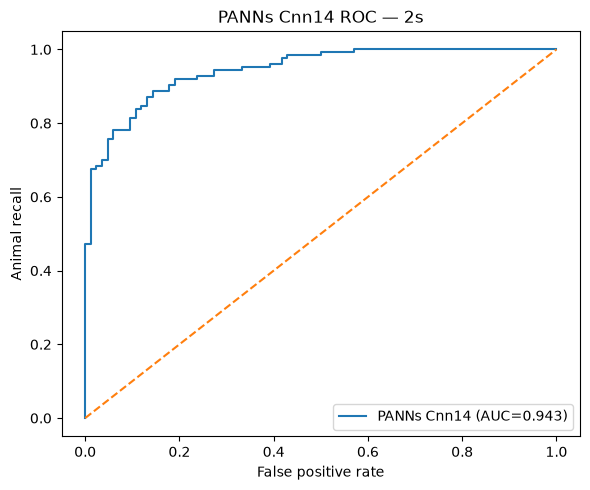

In [31]:
fpr, tpr, _ = roc_curve(
    y_test,
    test_prob,
)

plt.figure(figsize=(6, 5))

plt.plot(
    fpr,
    tpr,
    label=(
        "PANNs Cnn14 "
        f"(AUC={roc_auc_score(y_test, test_prob):.3f})"
    ),
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
)

plt.xlabel("False positive rate")
plt.ylabel("Animal recall")
plt.title(
    f"PANNs Cnn14 ROC — {CONTEXT_SECONDS:g}s"
)
plt.legend()
plt.tight_layout()
plt.show()


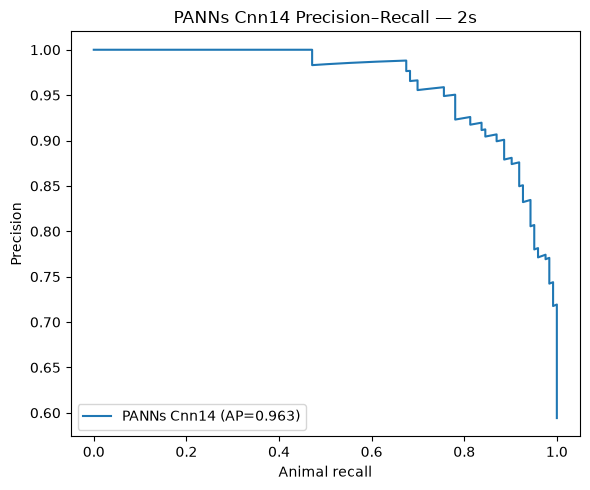

In [32]:
precision, recall, _ = (
    precision_recall_curve(
        y_test,
        test_prob,
    )
)

plt.figure(figsize=(6, 5))

plt.plot(
    recall,
    precision,
    label=(
        "PANNs Cnn14 "
        f"(AP={average_precision_score(y_test, test_prob):.3f})"
    ),
)

plt.xlabel("Animal recall")
plt.ylabel("Precision")
plt.title(
    f"PANNs Cnn14 Precision–Recall — "
    f"{CONTEXT_SECONDS:g}s"
)
plt.legend()
plt.tight_layout()
plt.show()


In [33]:
test_rows = eligible.loc[
    test_mask
].copy()

test_rows[
    "animal_probability"
] = test_prob

site_rows = []

for site_id, group in (
    test_rows.groupby("site_id")
):
    metrics = binary_gate_metrics(
        group["binary_label"].to_numpy(),
        group[
            "animal_probability"
        ].to_numpy(),
        threshold,
    )

    site_rows.append({
        "site_id": site_id,
        "samples": len(group),
        "animal_samples": int(
            (
                group["binary_label"]
                == 1
            ).sum()
        ),
        "background_samples": int(
            (
                group["binary_label"]
                == 0
            ).sum()
        ),
        **metrics,
    })

site_results = pd.DataFrame(
    site_rows
)

display(
    site_results[
        [
            "site_id",
            "samples",
            "animal_samples",
            "background_samples",
            "animal_recall",
            "false_negative_rate",
            "background_rejection",
            "overall_vision_skip_rate",
            "safe_vision_skip_rate",
        ]
    ].round(4)
)


,site_id,samples,animal_samples,background_samples,animal_recall,false_negative_rate,background_rejection,overall_vision_skip_rate,safe_vision_skip_rate
0,S1,48,42,6,0.9048,0.0952,0.6667,0.1667,0.0833
1,S2,47,38,9,0.9737,0.0263,0.1111,0.0426,0.0213
2,S3,112,43,69,0.9767,0.0233,0.7101,0.4464,0.4375


In [34]:
metrics_df = pd.DataFrame(
    [
        {
            "model":
                "panns_cnn14_frozen_embedding_head",
            "context_s":
                CONTEXT_SECONDS,
            "split":
                "validation",
            "roc_auc":
                roc_auc_score(
                    y_val,
                    val_prob,
                ),
            "pr_auc":
                average_precision_score(
                    y_val,
                    val_prob,
                ),
            **val_metrics,
        },
        {
            "model":
                "panns_cnn14_frozen_embedding_head",
            "context_s":
                CONTEXT_SECONDS,
            "split":
                "test",
            "roc_auc":
                roc_auc_score(
                    y_test,
                    test_prob,
                ),
            "pr_auc":
                average_precision_score(
                    y_test,
                    test_prob,
                ),
            **test_metrics,
        },
    ]
)

metrics_df.to_csv(
    METRICS_PATH,
    index=False,
)

site_results.to_csv(
    RESULTS_DIR
    / f"panns_cnn14_site_results_{CONTEXT_TAG}s.csv",
    index=False,
)

config = {
    "model":
        "PANNs Cnn14",
    "checkpoint":
        str(PANNS_CHECKPOINT_PATH),
    "sample_rate":
        PANNS_SAMPLE_RATE,
    "context_seconds":
        CONTEXT_SECONDS,
    "embedding_dim":
        2048,
    "head_hidden_dim":
        HEAD_HIDDEN_DIM,
    "head_dropout":
        HEAD_DROPOUT,
    "target_animal_recall":
        TARGET_ANIMAL_RECALL,
    "selected_threshold":
        threshold,
    "random_seed":
        RANDOM_SEED,
    "backbone_parameters":
        int(backbone_parameters),
    "head_parameters":
        int(head_parameters),
}

CONFIG_PATH.write_text(
    json.dumps(
        config,
        indent=2,
    )
)

print("Saved:")
print(" -", HEAD_PATH)
print(" -", METRICS_PATH)
print(" -", CONFIG_PATH)

display(
    metrics_df.round(4)
)


Saved:
 - models\panns_cnn14_binary_head_2p0s.pt
 - results\panns_cnn14_metrics_2p0s.csv
 - results\panns_cnn14_config_2p0s.json


,model,context_s,split,roc_auc,pr_auc,threshold,accuracy,precision_animal,animal_recall,false_negative_rate,f1_animal,background_rejection,overall_vision_skip_rate,safe_vision_skip_rate,tn,fp,fn,tp
0,panns_cnn14_frozen_embedding_head,2.0,validation,0.8867,0.9696,0.1662,0.8414,0.8594,0.9565,0.0435,0.9053,0.4000,0.1172,0.0828,12,18,5,110
1,panns_cnn14_frozen_embedding_head,2.0,test,0.9432,0.9626,0.1662,0.8261,0.7959,0.9512,0.0488,0.8667,0.6429,0.2899,0.2609,54,30,6,117
